# ENEL 441 Lab 1
# Understanding The Frequency Domain Representation

In this lab we will construct a Bode plot of a system using physical measurements. 

# Learning Objectives:
- See that for a sinusoidal input, the output of a (LTI) system is a sinusoid at the same frequency, but with different magnitude and phase.
- Understand how the magnitude change caused by the (LTI) system can be plotted vs frequency to generate the magnitude portion of the Bode plot.
- Gain deeper understanding of the connections between time-domain, frequency domain and Laplace domain.
- Gain deeper understanding of what a resonance peak is.

# What is frequency domain?

Based on two facts:
- every signal can be expressed as a weighted sum of sinusoids of different frequencies,
- for a sinusoidal input, the output of a LTI system is a sinusoid at the same frequency, but with different magnitude and phase.

# Bode Plot - Visualizing the Frequency Domain

Bode plot consists of two plots: 
- x-axis of both plots is frequency (usually in radians). Axis is logarithmic.
- y-axis of top plot is called the Magnitude plot.
- y-axis of bottom plot is called Phase plot.

To construct a Bode Plot of $G(s)$:
1. excite the system with a sinusoid of frequency $\omega$ with unit magnitude and known phase
2. determine the magnitude of phase shift of the output sinusoid
3. plot the magnitude of the output on the top plot (a point at frequency $\omega$)
4. plot the phase shift of the output on the bottom plot
5. Return to step one for a new frequency $\omega$.


## What is Laplace Domain?

Based on the concept of a transfer function. A transfer function is a way of encoding the governing differential equation of a system. A transfer function has poles and zeros. 

In the lectures we have learned that to represent a transfer function $G(s)$ in Frequency domain, all we have to do is set $s = j\omega$. In this lab we will fit a transfer function to the Bode Plot data that you will collect from the physical system. 


# Physical Setup

This lab will also serve as an introduction the lab equipement that you will use in subsequent labs. 

In this lab we will be using pySerial to send data to and from the Arduino through a USB connection. Because Python needs to connect to a COM port on your computer you cannot use Colab or another cloud based IDE to run Python. Please use a locally installed Python IDE to run the lab notebook. For instructions on how to install jupyter notebooks using miniconda see the document posted on D2L. 

All the labs in ENEL441 will use the following Python packages:
- numpy
- scipy
- matplotlib
- pyserial
- control

If you do not have these packages installed, you need to install them now. The pySerial package can be installed using the following instructions.  

## Installation:
pySerial can be installed using pip: 

>pip install pyserial

or Conda:

>conda install pyserial

Run the following cell and make sure that it completes without errors. 

The control package can be installed using

> conda install -c conda-forge control 

In [5]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import serial
import ENELX41_lab_util as lu
import control as ct

# Hardware Setup

Now that you have the correct software installed, you are ready to setup the hardware. 

![motor](motor4.JPG "Motor")

This figure shows the motor. The motor is used to drive the system. A voltage is applied to the motor via a circuit called an H-bridge (more on this circuit below).

![encoder](encoder4.JPG "Encoder")

This figure shows the encoder. The encoder is used to read the position of the disk. Inside the encoder there is a little wheel that has 2048 lines evenly spaced along its circumference. Using an optical circuit (an LED), it is possible to count how many ticks the wheel has moved. This is how we can determine the position of the disk.

![encoderInsider](encoderInside2.png "Encoder Inside")

This figure shows the inside of the encoder. The lines along the outside a so close together they appear as a shaded gray area.

![circuit](circuit4.JPG "Circuit")

This figure shows the circuit we will use. It consists of an Arduino and an H-Bridge. The Arduino stores the signal to apply to the motor and communicated with the PC. A motor requires 12-15V and 0-2A to run, so the Arduino cannot be used to directly drive the motor. The H-bridge is used to do this. It has its own power supply and is connected to both the Arduino and the motor. 


Connect all the cables as shown in the picture below. In total, you will need to attach 4 cords:
1. Plug in the power adapter from the power bar to the ENEL441 Motor card. This is a 12V supply for the motor. 
2. Plug in the banana plug from the ENEL441 Motor card to the setup. This connects the H-bridge to the motor itself.
3. Plug in the 5-wire cable to the black encoder. 
4. Plug in the USB cable between your computer and the Arduino. We will use the USB connection to send data back and forth. The USB connection is also used to power the Arduino. You should see LEDs turn on in the Arduino to indicate that it is powered. 

# Communicating with the Arduino

In order to send data to and from the Arduino, we need to know which COM port the Arduino is connected to. Depending on if you have Windows or Mac, there is a different way to determine the COM port that the Arduino is attached to:

# Windows:

1. Open the Device Manager of your computer. Follow the instructions in the figure to do this.
![openingdevicemanger](openingDeviceManager.png "Opening Device Manager")

2. In the Device Manager click on the ">" symbol to expand the "Ports (COM & LPT)" tab. You will see a list of all the peripherals connected to your computer. There should be a device listed as "USB Serial Device". This is the Arduino. TO make sure that this device is corresponds to the Arduino, you can unplug the Arduino, the device should disappear from the list of connected devices. THen when you plug the Arduino back in, it should re-appear in the list. Note the COM port that the Arduino is connected to. Enter the COM port number in the code below. 

# Mac:
![findingCOMportMac](findingCOMportMac.png "Finding COM port Mac")

# COM Port

Enter the name of your COM port in the line of code below.

In [14]:
#arduino_com_port = '/dev/ttyACM0'  ### Enter the com port of your system here. For example 'COM3'
arduino_com_port = 'COM10'

# Testing the system

In the next few steps we will check and make sure that the system is running correctly. We will send a $0$ V signal to the motor. So the motor will not move. You will manually move the disks. We will look at the recorded data and make sure that it looks OK. 

Note: When manually moving the disks, please turn the blue metal spacer (see photo in introduction) by the motor only. Manually turning the disks or plastic spacers is more likely to damage the system.

Run the following cell. Here we are constructing an array of zeros. 

Note: You can only send signals consisting of 1000 points to the Arduino. This is a hard coded constant in this setup. It means that we can only run simulations that last 20s. The main limitation is the memory of the Arduino. 

In [3]:
N = 1000    #data length. Our simulation will be 10 seconds long. 
            #The sampling rate of the system is 100 samples per second

counts_per_revolution_to_rad = 1/2048*2*np.pi
            
t = np.linspace(0,10-10/N,N)
u0 = np.zeros(N)  # The test input we will send to the motor is signal that is 0V for the entire 10 seconds.

# H-Bridge

The H-bridge has a separate circuit to handle the direction of rotation of the motor, and the speed of rotation of the motor. So we need to separate the input that we want to send to the motor into a magnitude and a direction (positve or negative). The following line of code splits in the input signal into a magnitude and direction. In addition the magnitude must be a number between 0-255 (one byte), and the direction must be one bit.

In [4]:
u0_mag, u0_dir = lu.signal_to_mag_and_dir(u0)

# The Test

The following line of code will send the input arrays to the Arduino. Once it has sucessfully recieved the data it will print a message that says "Simulation is Running". Once you see this message, turn the disks 45 degrees or so in both directions using the blue metal spacer next to the motor. The simulation will last 20s. After 20s has elapsed you will see a message "Simulation has ended. Retrieving data." in the notebook cell. The Arduino will then send the recorded encoder data to Python. We will then plot the data to see what it looks like and determine if it looks OK. 

Note: Sending and retrieving data is quite slow at the moment. This is because I manually implemented handshaking. You will know that the communication is done when you see the message "Completed.' printed in the notebook cell.

Run the following line of code now. If you get any error messages please call over a TA.

Note: recall that we are sending a signal of $0$ V to the motor, so it will not do anything. For this test, you must manually move the motor. The disk position will be recorded by the encoder.

In [7]:
measured_outputs = lu.run_motor_and_disk_open_loop_streaming(u0_mag,u0_dir,com_port=arduino_com_port)

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


# Plotting the measured data

The measured data is stored in an array called "measured_outputs". Run the following code to plot the encoder data. You should see that you moved the disk roughly 45 degrees one way and the other.

Text(0, 0.5, 'Position (rad)')

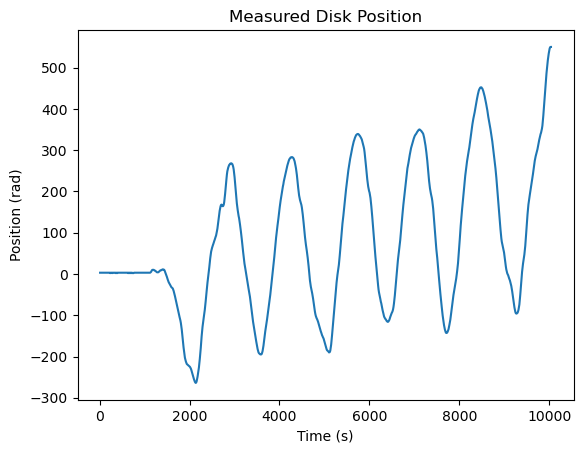

In [9]:


disk_position_measured = measured_outputs[0]
dt_measured = measured_outputs[1]
t_measured = np.cumsum(dt_measured)


fig,ax = plt.subplots(1)
ax.plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax.set_title('Measured Disk Position')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (rad)')

# Experiment

Now you are ready to start the experiment. In this lab we will be constructing the magnitude portion of a Bode plot for the motor and disk system. 

We will do this by applying a sinusoid to the system with a particular frequency. Because we have (roughly) a linear, time invariant system, the output will also be a sinusoid with the same frequency, but a different magnitude and phase. We will determine the magnitude of the measured output sinusoid. 

We will repeat these steps for sinusoids of different frequencies. Then at the end we will be able to construct a plot with frequencies along the x-axis and the magnitude of the resulting output sinusoid along the y-axis. This is exactly equal to the magnitude portion of the Bode plot. 

# Applying a sinusoidal voltage to the motor. 

Use the following cell to construct a sinusoidal input. Choose the frequency $1.5$ Hz to start.

IMPORTANT NOTE: If using the equipment with a red encoder attached to the motor, use a magnitude of 100 for the sinusoidal inputs. If using the equipment with a black encoder attached to the motor (and 3d printed housing for the motor), use a magnitude of 200 for the sinusoidal inputs. 

In [10]:
f = 1.5                      #frequency of sinusoid in Hz
u1 = 200*np.sin(2*np.pi*f*t)    #the sinusoidal input. IMPORTANT NOTE! If using the equipment with a red encoder attached to the motor, 
                                #use a magnitude of 100 for the sinusoidal inputs. If using the equipment with a black encoder 
                                # attached to the motor (and 3d printed housing for the motor), use a magnitude of 200 for the sinusoidal
                                # inputs. 

# Magnitude and Direction

Use the following cell to split the input into a magnitude and direction. Does the plot make sense?

Text(0, 0.5, 'Direction')

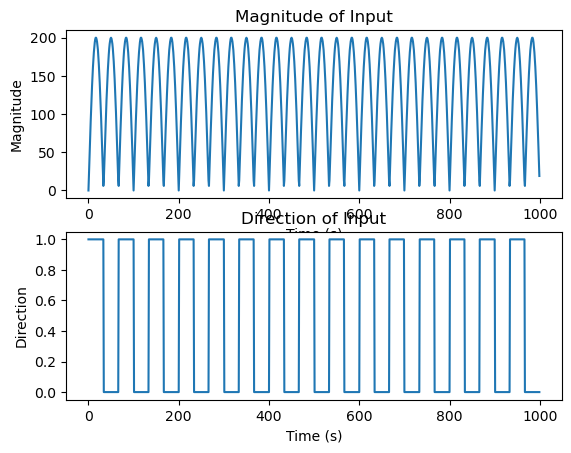

In [11]:
u1_mag, u1_dir = lu.signal_to_mag_and_dir(u1)

fig,ax = plt.subplots(2,1)
ax[0].plot(u1_mag)
ax[0].set_title('Magnitude of Input')
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Magnitude')
ax[1].plot(u1_dir)
ax[1].set_title('Direction of Input')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Direction')

# Run the experiment

Run the following cell to send the sinusoidal input the motor, and record the output. This time, when you run the simulation, the motor will move (sinusoidally). Make sure the the setup is free to move, and not going to hit anything. 

In [17]:
measured_outputs = lu.run_motor_and_disk_open_loop_streaming(u1_mag,u1_dir,com_port=arduino_com_port)

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


# Plot the Measured Data

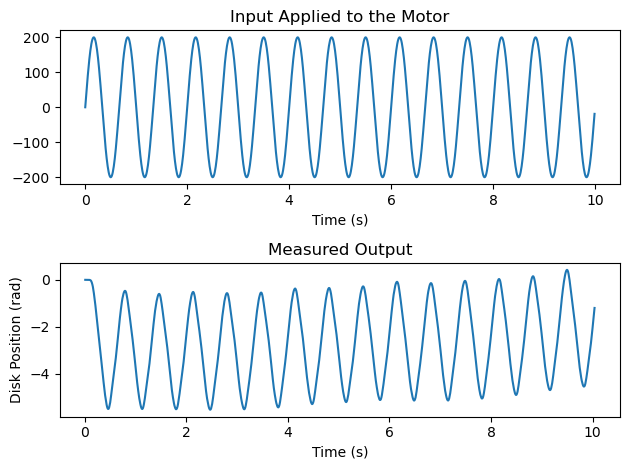

In [18]:
disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad
dt_measured = measured_outputs[1]
t_measured = np.cumsum(dt_measured)/1000


fig,ax = plt.subplots(2,1)
ax[0].plot(t,u1)
ax[0].set_title('Input Applied to the Motor')
ax[0].set_xlabel('Time (s)')
ax[1].plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax[1].set_title('Measured Output')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Disk Position (rad)')
fig.tight_layout()

# Observations

Does the output signal match what you expected? 
- Is it sinusoidal?
- Is there an initial transient response (repsonse due to intial conditions)?
- Does it have the same frequency as the input?
- Does it have the same magnitude as the input?
- Does it have the same phase as the input?
- Is the signal zero mean?

1. yes, it is sinusoidal in that it has a periodic up and down value. However, it is not a sin/cos function as it has a trend
2. Yes, there is an initial transient response. The system behaves different during the first second of the experiment
3. It appears to have the same frequency as the input
4. No, it has a smaller magnitude than it's input
5. No, when comparing the 2 graphs, the output appears to be shifted left compared to the input
6. No, the signal is not zero mean, as it stays below zero for almost the entire time. It also has an upward trend.

Overall, while the output is a sinusoid at the same frequency with different magnitude and phase compared to the input, it also contains a trend and transient adding noise to the result.

# Detrending the Output

You may notice the the output signal is not zero mean, and it can have a slight drift (or trend). 

The reason why the signal is not zero mean is because we have assigned the starting position to be $0$ rad. 

The main reason for the drift is because the gears and the connections between the rods are not perfect and can wiggle a little bit, causing a drift over time. 

We want to remove this drift, and also center the signal so that it is zero-mean. The scipy package has a function that does this for us. It is called sp.detrend. 

Run the following cell to plot the detrended data.

Text(0, 0.5, 'Position of disk (rad)')

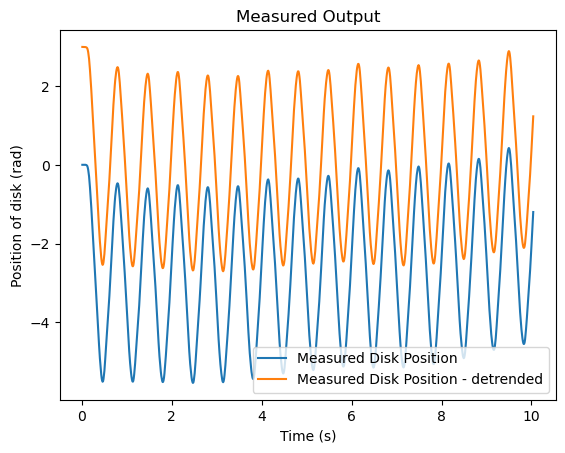

In [19]:
detrended_disk_position = sp.signal.detrend(disk_position_measured)


fig,ax = plt.subplots(1)
ax.plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax.plot(t_measured,detrended_disk_position,label='Measured Disk Position - detrended')
ax.legend()
ax.set_title('Measured Output')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position of disk (rad)')


# Compare

Compare the orginal output and the detrended output. What are the differences? Does the function appear to be doing what we intend?

The differences are the detrended position has been shifted up to be between a positive value (just above 2 rad) and a negative value (just below 2 rad), compared to the original which has values with a maximum of 0. The detrended position is also much more stable, compared to the original which has an upward trend.

It appears to be doing what we intended as it appears to have a zero mean and appears to have less of a trend. However, the trend isn't fully stable.

# Determining the Magnitude of the Output

In this lab, we are interested in the magnitude of the output sinusoid. 

There are several ways of determining the magnitude of the output. We will look at two of them; a time domain method and a frequency domain method. This will further emphasize to you the connection between time domain and frequency domain.

# Time Domain Approach

From the detrended measured sinusoid, determine the maximum (or minimum) value of the signal. This is the magnitude of the sinusoid. 

Note: if your output had a significant transient response, make sure that you do not include this portion of the signal in your calculation of the amplitude of the sinusoid. We are only interested in the steady state behavior of the system.

In [44]:
# write your code here to determine the max or min of the detrended output sinusoid. 
edgeBoundary = int(detrended_disk_position.size*0.2)  #truncated data to remove transient, and keep stable data (2s-8s)

maxValue = np.max(detrended_disk_position[edgeBoundary:-edgeBoundary])
print('Magnitude:',maxValue)

Magnitude: 2.563163158814816


# Frequency Domain Approach

The time domain approach is sensitive to trends in the data. We can also determine the magnitude of the sinusoid from the frequency domain representation of the signal. 

In Python we can calculate the Fourier Transform using the np.fft.fft function. 

What should the Fourier Transform of a single sinusoid look like?
    
    The Fourier Transform of a single sinusoid should ideally be a spike with half the magnitude at +/- $2\pi f_{0}$

Use the code below to plot the Fourier Transform of the measured sinsoid and see if it matches your expectation.

Consider a few comments:
- The DC offset of the signal will appear at $f=0$ (a sinusoid with frequency of $0$ Hz).
- For the given sampling frequency of the system ($100$ samples/s the maximum frequency that can be represented is $50$ Hz (you will learn more about this in digital filtering or digital control)
- Frequency resolution of the sample points is $100$ samples/s / $1000$ samples  $= 0.1$ Hz.
- The second half of the plot is a mirror image of the first half, so you only should look at the first $500$ points. 

Note: calculate the Fourier Transform of the detrended measured output. If you use the undetrended output you will see a large DC gain, and low frequency smearing. Why?
    
    When taking the fourier transform of a trend, you theoretically get an infinite DC gain, which quickly decays with frequency (hence the low frequency smearing). Because the program cannot capture an infinite value, this is displayed as a finite high DC gain.

Text(0, 0.5, 'Magnitude (rad)')

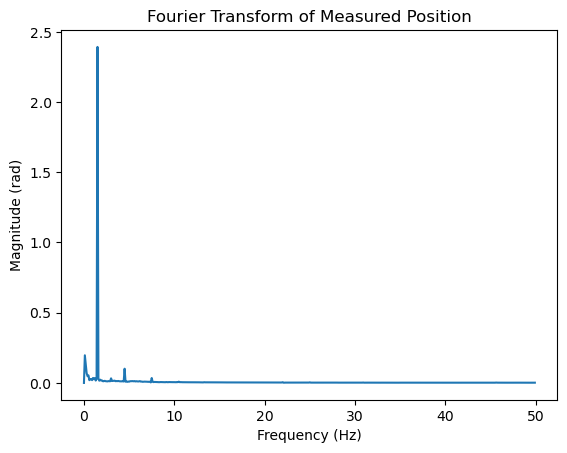

In [33]:
Y = np.fft.fft(detrended_disk_position)
f_vec = np.linspace(0,100-100/N,N)

fig,ax = plt.subplots(1)
ax.plot(f_vec[0:500],np.absolute(Y[0:500])/N*2)
ax.set_title('Fourier Transform of Measured Position')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (rad)')

# Do your results match?

Did you get roughly the same amplitude for the sinuoid using both methods? 

Yes, the amplitude in time was ~2.563163158814816 rad while the amplitude in frequency was ~2.45 rad

# TA check

Call over a TA to check your work. Be prepared to answer some questions about your results so far. 

# Constructing the Magnitude Portion of the Bode Plot

In the remainder of the lab you will repeat the procedure that you just did for a $1.5$ Hz sinusoid for sinusoids with different frequencies. 

Use the code above to apply sinusoids with the following frequencies to the motor: $0.3$ Hz to $8$ Hz in steps of $0.2$ Hz. 

Use the frequency domain method of calculating the magnitude of the sinusoid. It is more robust (you will get better estimates of the magnitude). 

Make sure that you always plot the measured signal and see what it looks like. 

You will need to write some code to store the magnitude, frequency, and the complex magnitude of the sinusoid for each experiment. The complex magnitude is just the value of the frequency response at the frequency of interest (the frequency that you excited the system at). It encodes both the magnitude and phase of the sinusoid. Let $a = b +jc$ be the complex magnitude of the sinusoid, then:
$$
\begin{align*}
Mag &= \text{abs}(a) = \sqrt{b^2+c^2} \\
Phase &= \text{angle}(a) = \text{atan}(\frac{c}{b})
\end{align*}
$$

Important note: it is very worthwhile to store each measured data set. This will help so that you can go back and fix a post-processing error after the fact, without having to redo the experiment. 

Once you have finished applying all the sinusoids to the system, you will plot the measured magnitude vs. frequency to construct the magnitude portion of a Bode plot. 

As you are applying the sinusoids keep the following questions in the back of your mind:
- What do you notice for the low frequencies?

        At low frequencies the system is relatively stable
- Do you notice anything different happening at around $2$ - $3$ Hz?

        Around 2-3Hz, the system begins gaining a trend
- What do you notice for the high frequencies ($4$ - $5$ Hz)?

        For high frequencies, there was a mix of more stable and downward trended results

Frequency 0.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


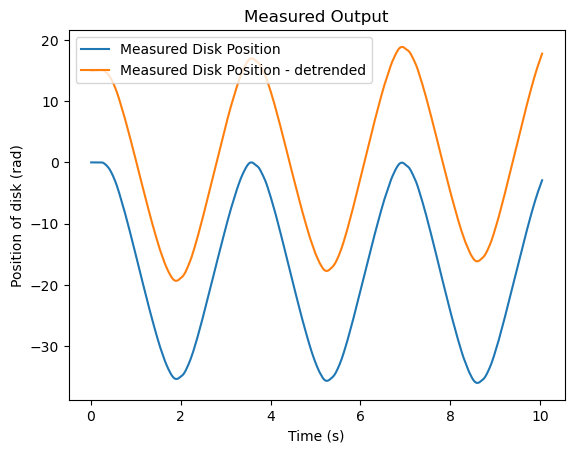

Frequency 0.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


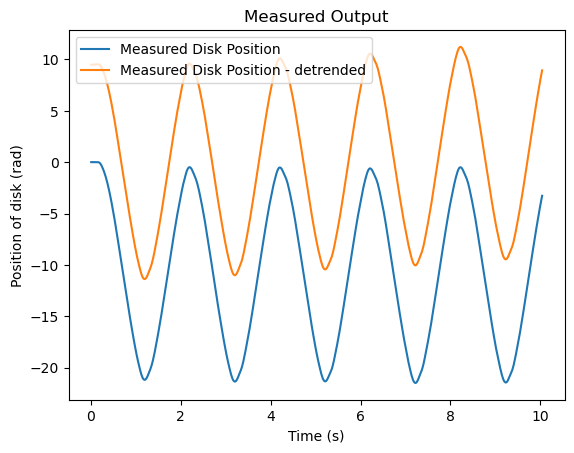

Frequency 0.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


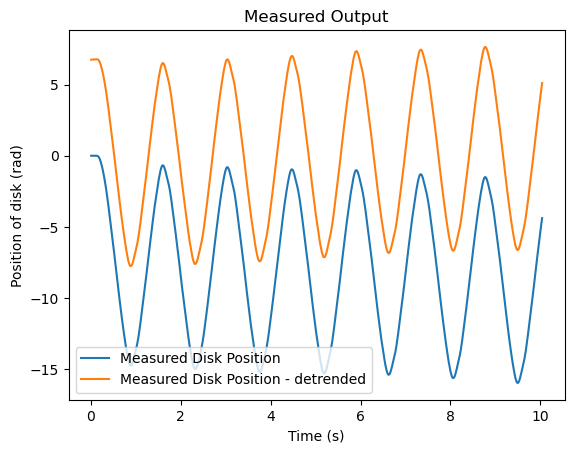

Frequency 0.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


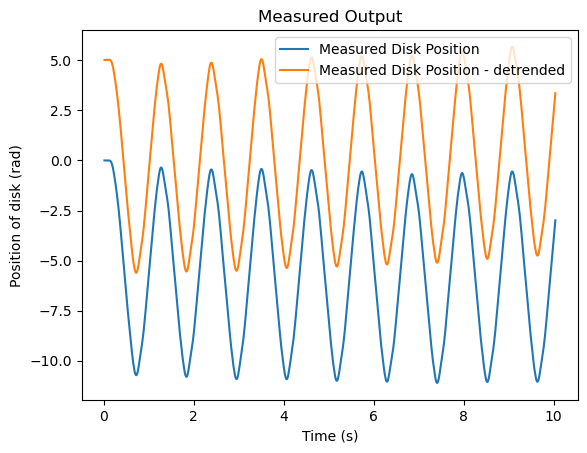

Frequency 1.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


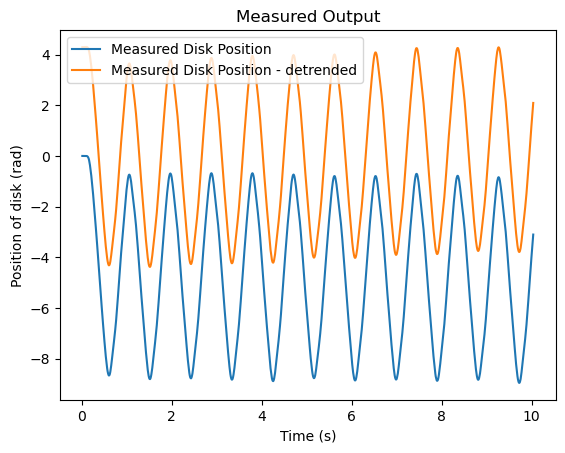

Frequency 1.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


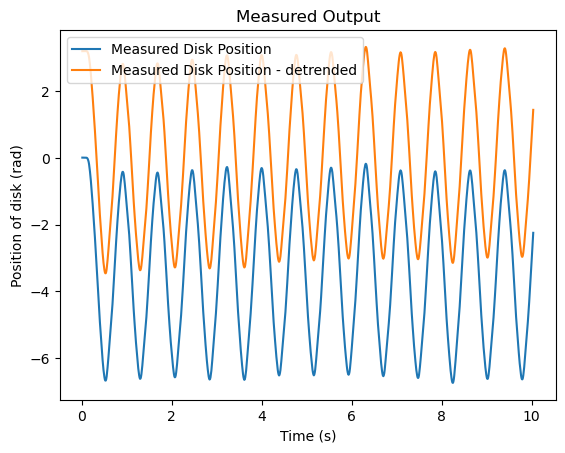

Frequency 1.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


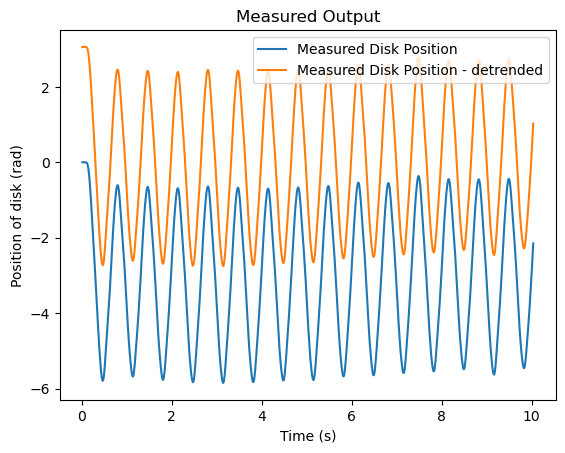

Frequency 1.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


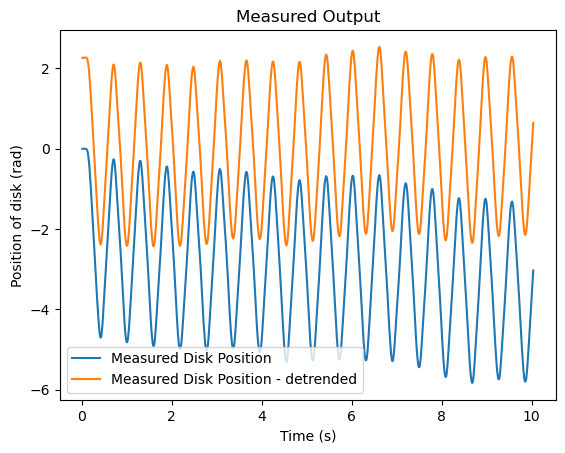

Frequency 1.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


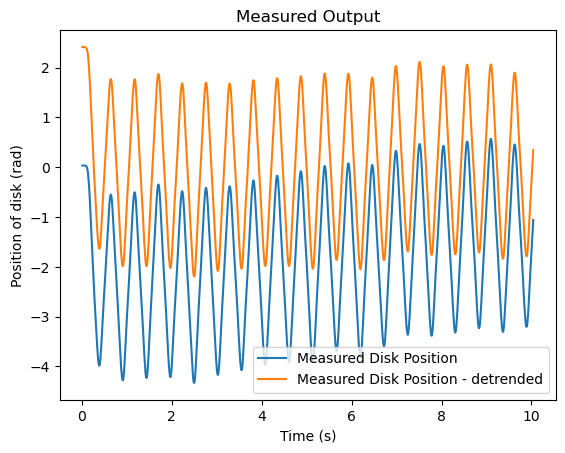

Frequency 2.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


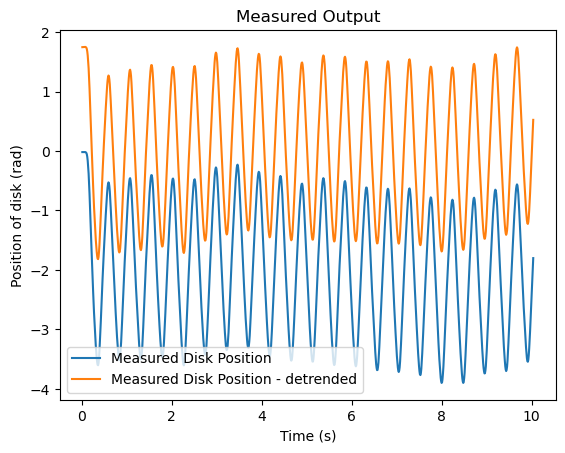

Frequency 2.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


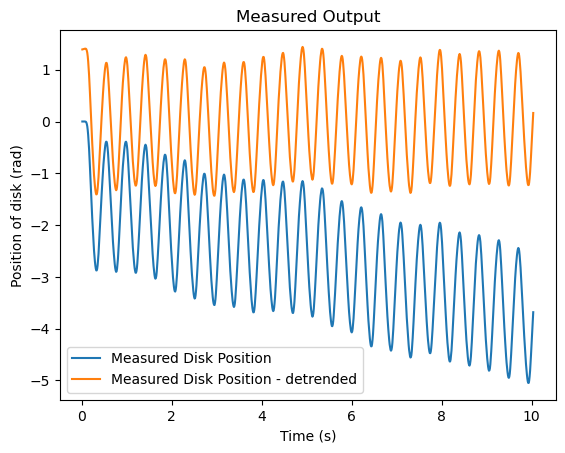

Frequency 2.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


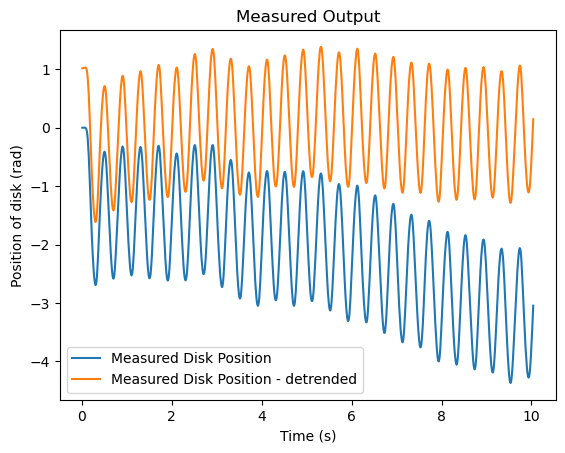

Frequency 2.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


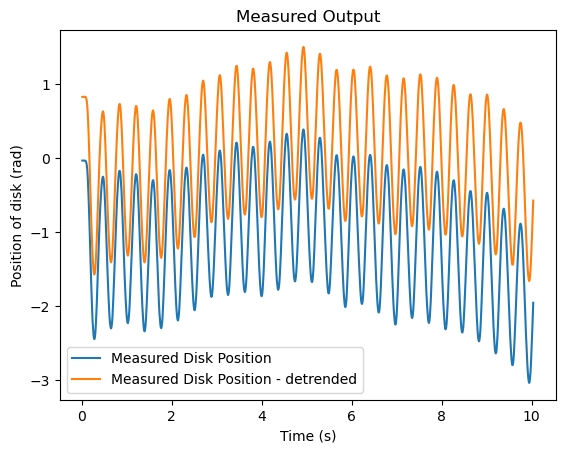

Frequency 2.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


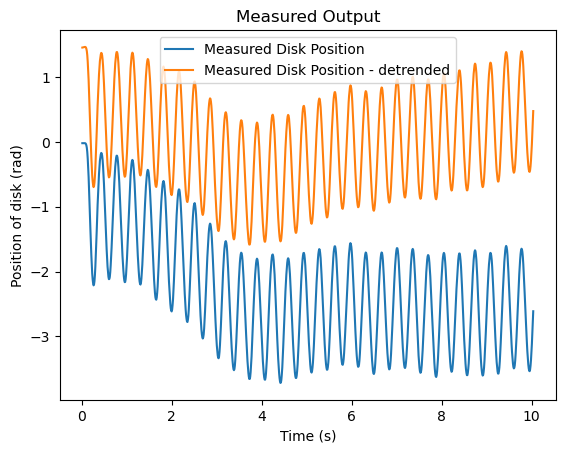

Frequency 3.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


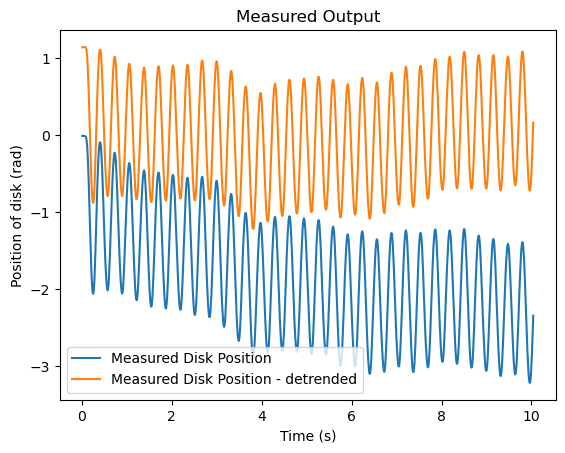

Frequency 3.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


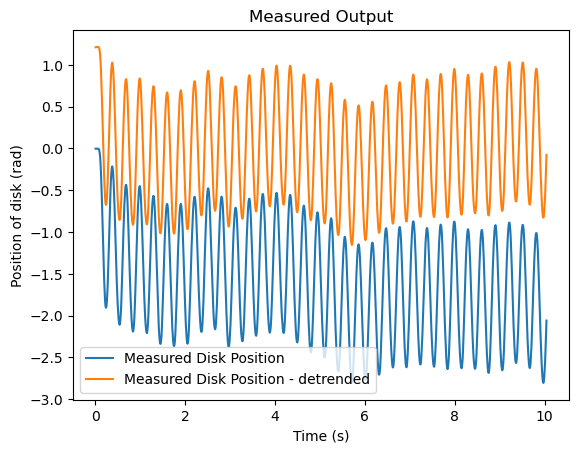

Frequency 3.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


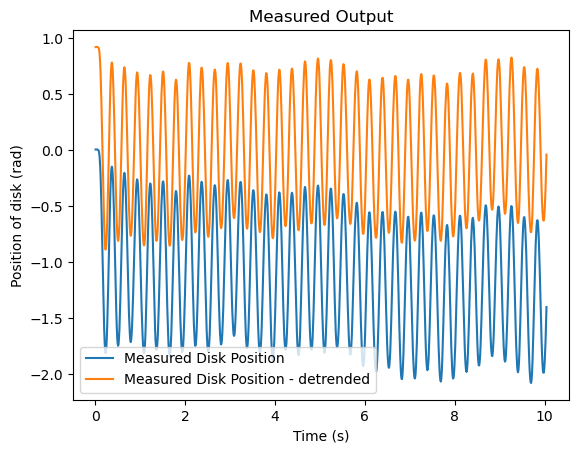

Frequency 3.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


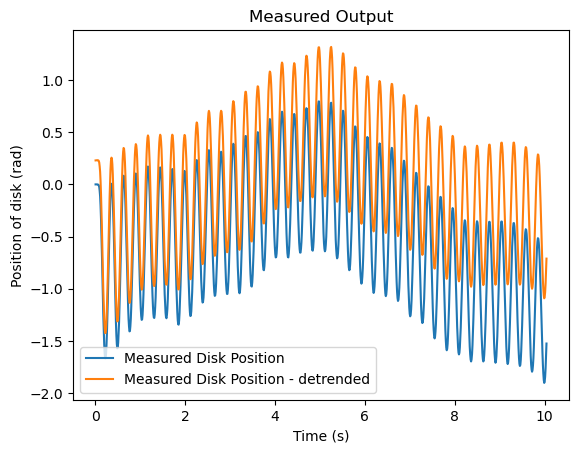

Frequency 3.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


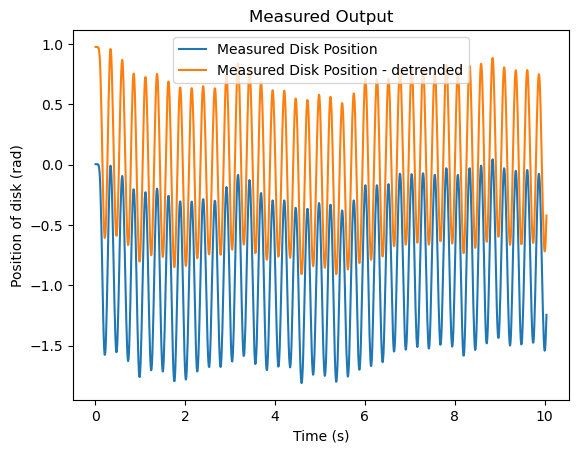

Frequency 4.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


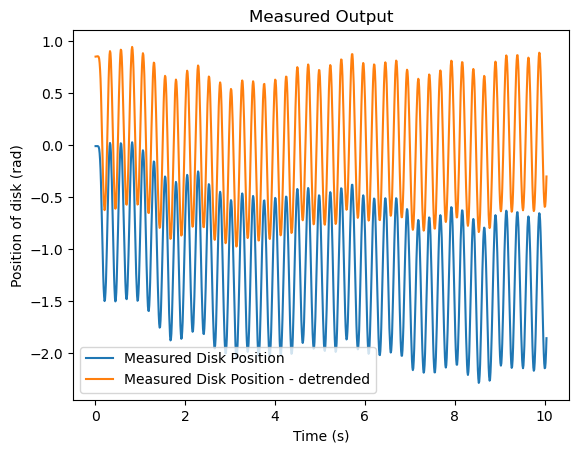

Frequency 4.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


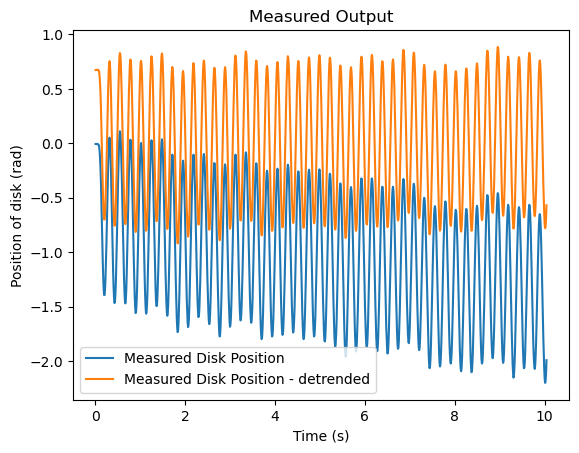

Frequency 4.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


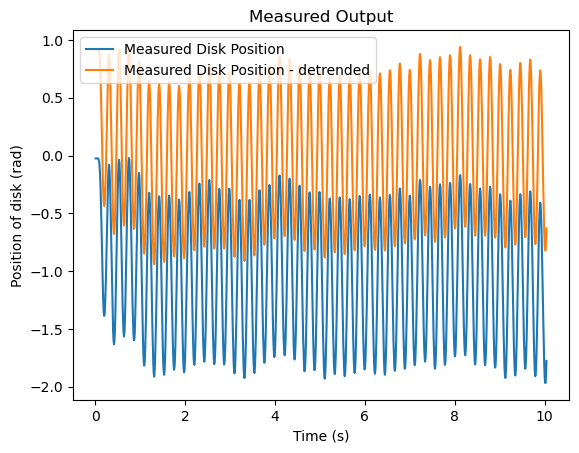

Frequency 4.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


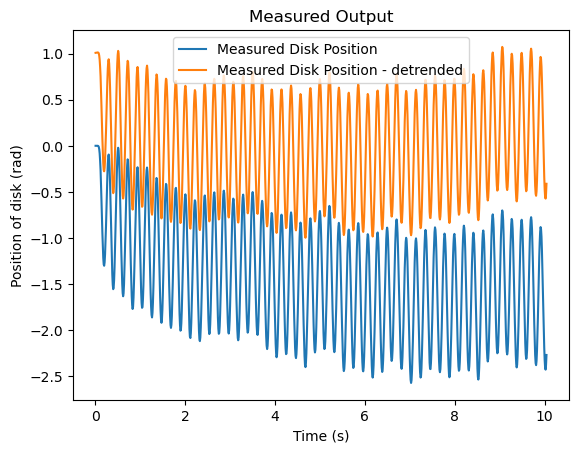

Frequency 4.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


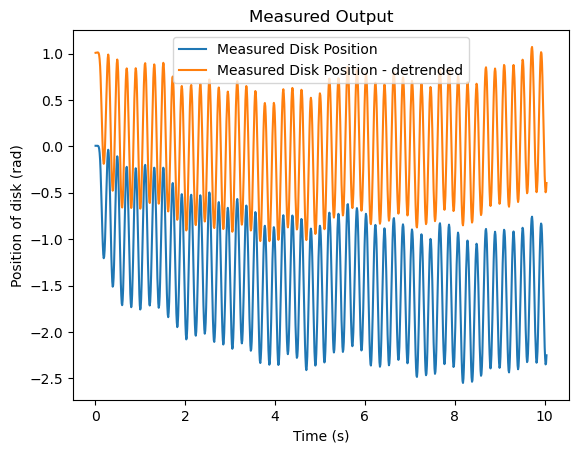

Frequency 5.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


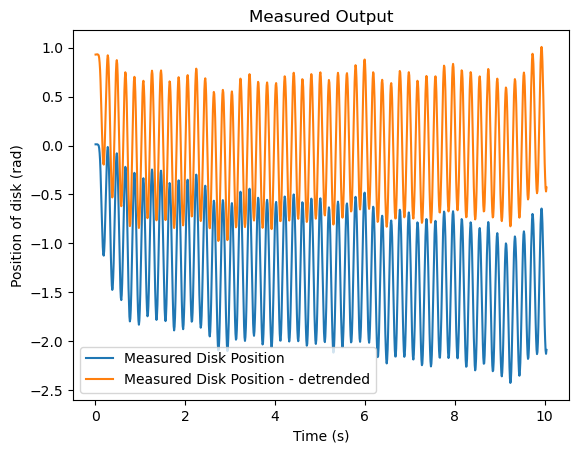

Frequency 5.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


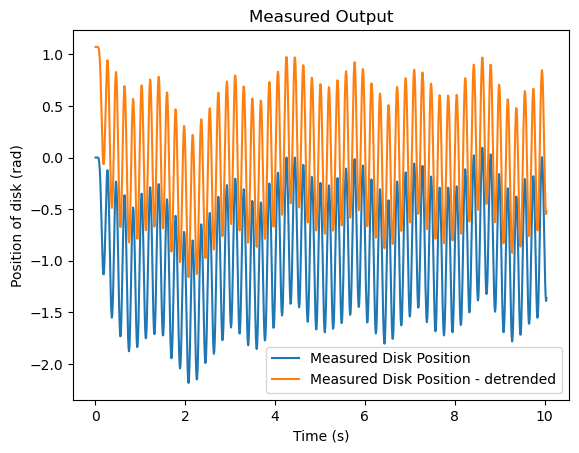

Frequency 5.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


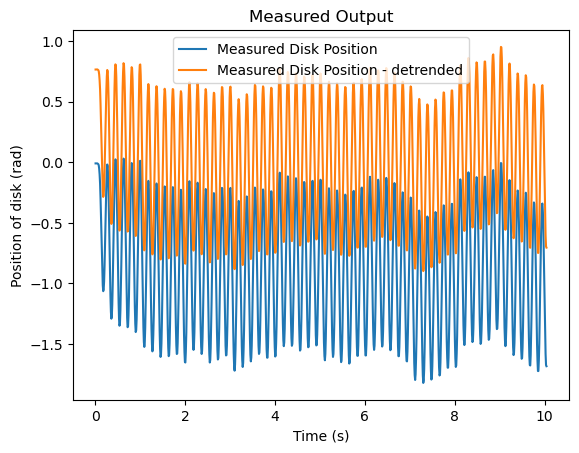

Frequency 5.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


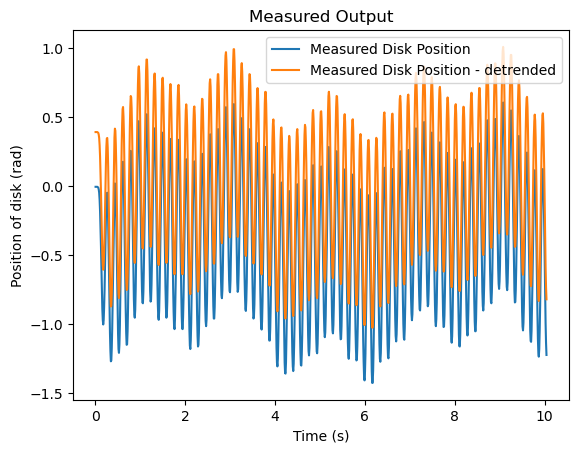

Frequency 5.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


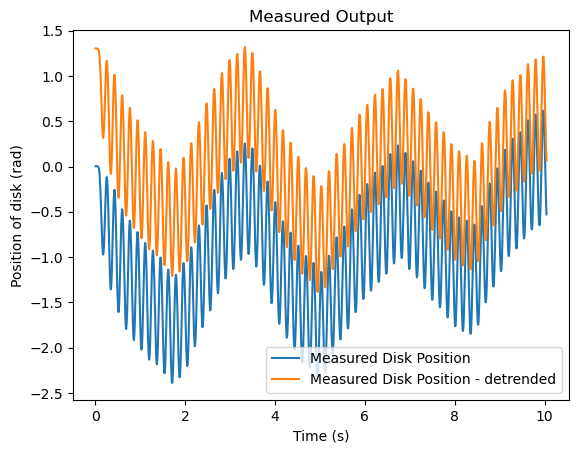

Frequency 6.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


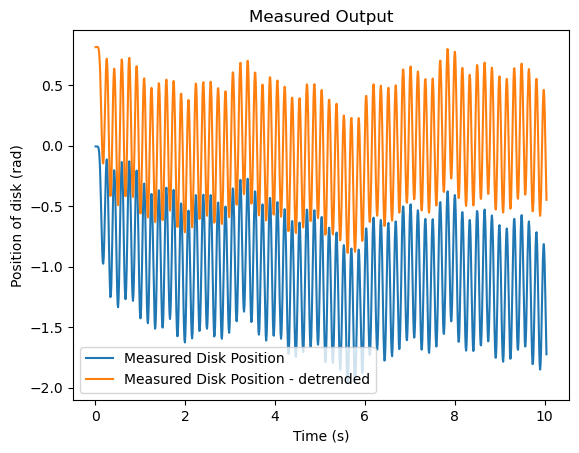

Frequency 6.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


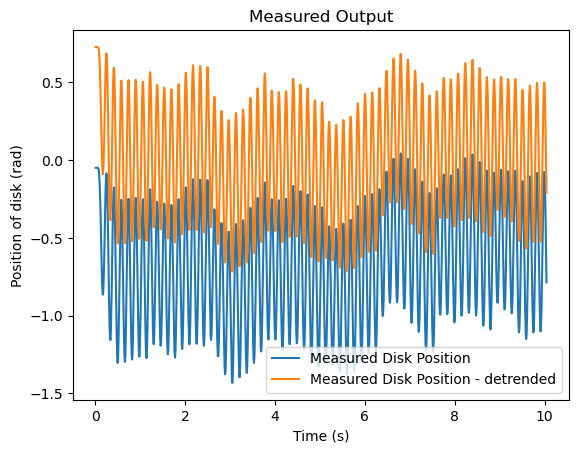

Frequency 6.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


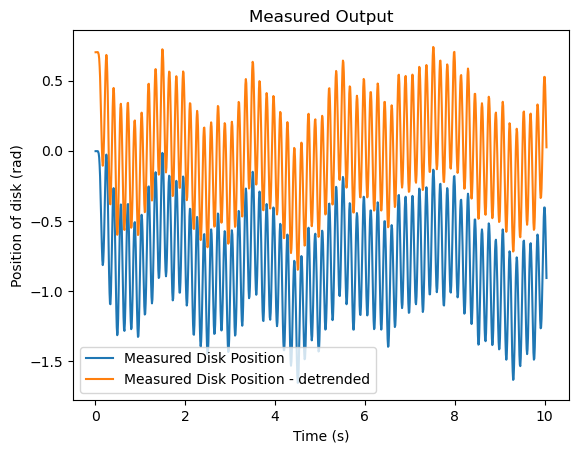

Frequency 6.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


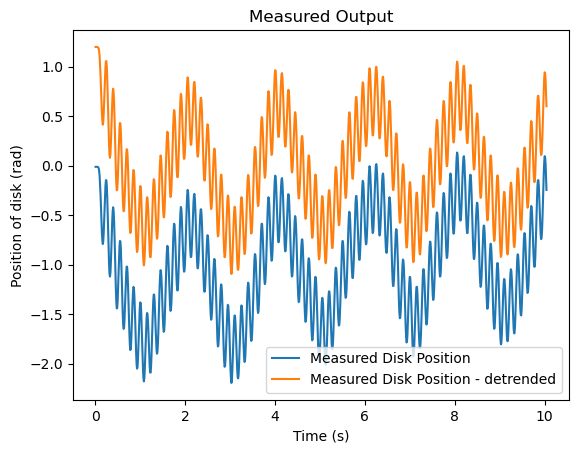

Frequency 6.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


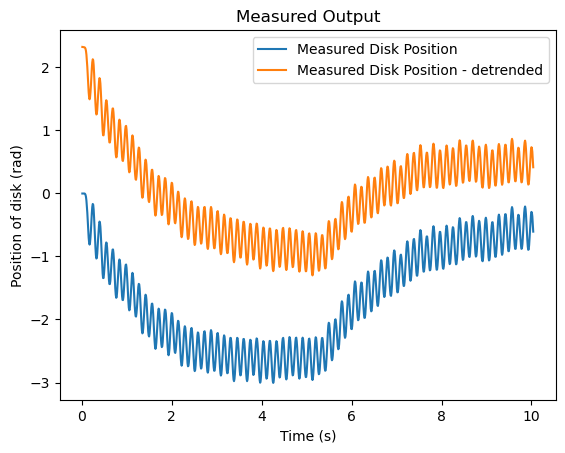

Frequency 7.1
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


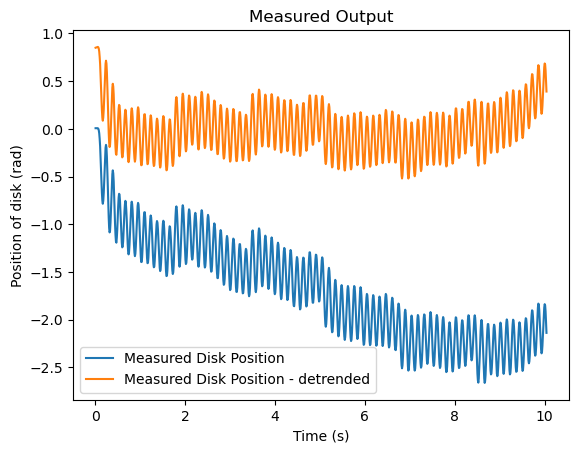

Frequency 7.3
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


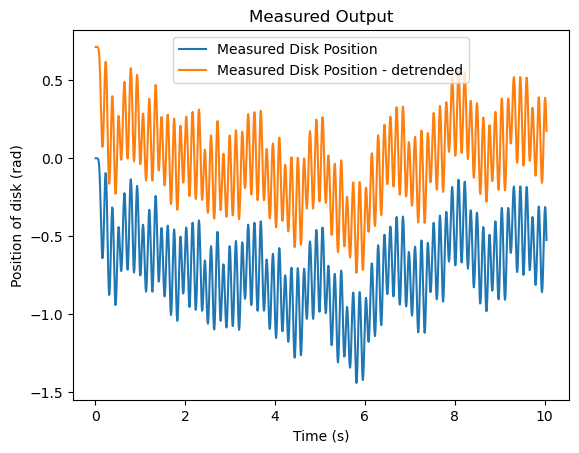

Frequency 7.5
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


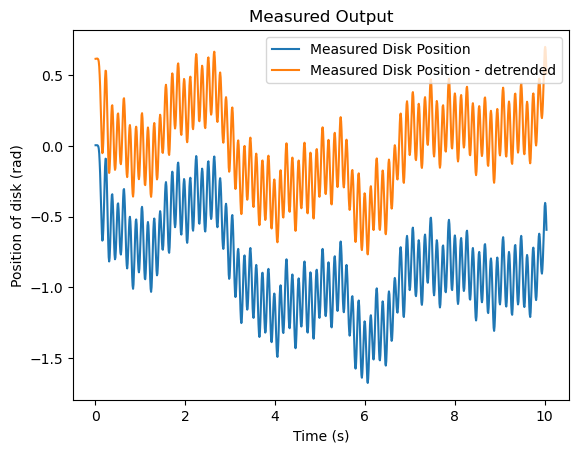

Frequency 7.7
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


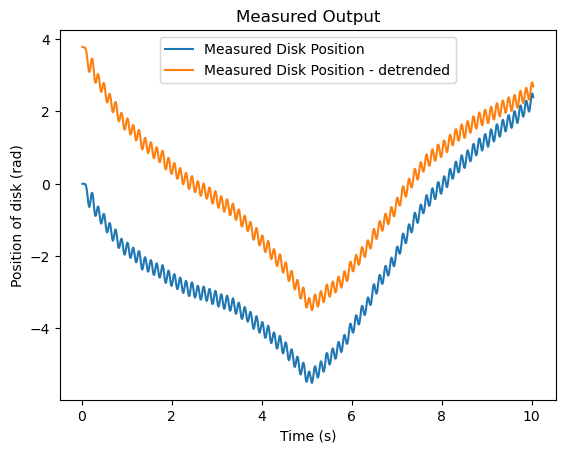

Frequency 7.9
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Simulation is running.
Simulation has ended.


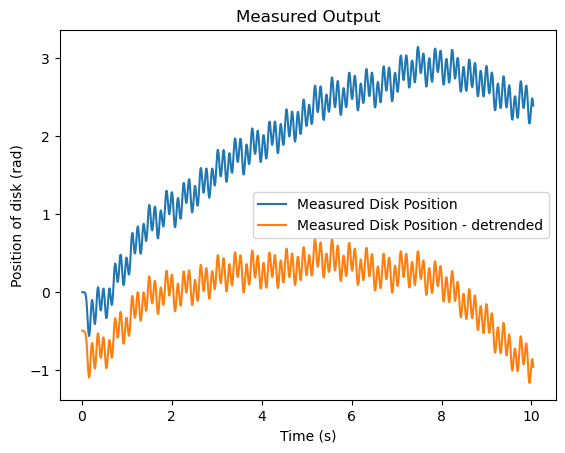

In [22]:
# Use this cell to write or copy/paste some code to collect your data 
# for the desired frequencies. 
# For each experiment, you need to estimate the amplitude of the measured sinusoid. 
# Store the raw data, complex magnitudes and amplitudes in an array (you will plot it later). 
N = 1000    #data length. Our simulation will be 10 seconds long. 
            #The sampling rate of the system is 100 samples per second

counts_per_revolution_to_rad = 1/2048*2*np.pi
            
t = np.linspace(0,10-10/N,N)
u0 = np.zeros(N)  # The test input we will send to the motor is signal that is 0V for the entire 10 seconds.
arduino_com_port = 'COM10'
f_vec = np.array([])
raw_data = np.array([])
complex_magnitude = np.array([])
amplitudes = np.array([])
phases = np.array([])


for f in range(3, 80, 2):
    f/=10

    print("Frequency", f)
    f_vec = np.append(f_vec, f) # <------
    u1 = 200*np.sin(2*np.pi*f*t)

    #run experiment
    u1_mag, u1_dir = lu.signal_to_mag_and_dir(u1)
    measured_outputs = lu.run_motor_and_disk_open_loop_streaming(u1_mag,u1_dir,com_port=arduino_com_port)

    #process results
    disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad
    detrended_disk_position = sp.signal.detrend(disk_position_measured)

    #get time value
    dt_measured = measured_outputs[1]
    t_measured = np.cumsum(dt_measured)/1000 


    #plot results
    fig,ax = plt.subplots(1)
    ax.plot(t_measured,disk_position_measured,label='Measured Disk Position')
    ax.plot(t_measured,detrended_disk_position,label='Measured Disk Position - detrended')
    ax.legend()
    ax.set_title('Measured Output')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position of disk (rad)')
    plt.show(block=False)


    raw_data = np.append(raw_data, detrended_disk_position) # <------


    freq_domain = np.fft.fft(detrended_disk_position)/N*2

    #find amplitude
    amplitude = np.absolute(freq_domain)

    #use index
    current_complex_mag = freq_domain[np.argmax(amplitude)]

    phases = np.append(phases, np.angle(freq_domain[np.argmax(amplitude)]))

    complex_magnitude = np.append(complex_magnitude, current_complex_mag) # <------
    amplitudes = np.append(amplitudes, np.abs(current_complex_mag)) # <------

np.savetxt("raw_data.csv", raw_data, delimiter=",")
np.savetxt("amplitude.csv", amplitudes, delimiter=",")
np.savetxt("phase.csv", phases, delimiter=",")
np.savetxt("comp_mag.csv", complex_magnitude, delimiter=",", fmt='%s')
np.savetxt("frequency.csv", f_vec, delimiter=",")


# Bode plot

In the cell below construct the magnitude portion of the Bode plot for this system using the data that you have collected. 

Text(0, 0.5, 'Magnitude (rad)')

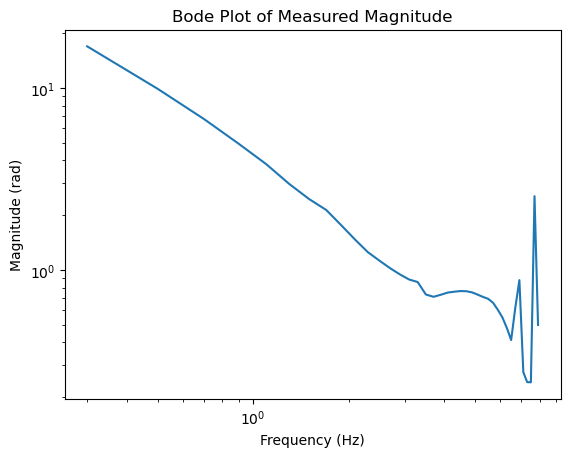

In [30]:
# Write code here to plot the magnitude portion of the Bode plot for the data you collected


fig,ax = plt.subplots(1)
plt.xscale('log')
plt.yscale('log')
ax.plot(f_vec,amplitudes)
ax.set_title('Bode Plot of Measured Magnitude')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (rad)')


# Estimate a Transfer Function

In this section you will fit a transfer function to your measured Bode Plot. Use the following code to estimate the transfer function. Print out the estimated transfer function. 

Make a plot with both the measured frequency response, and the frequency response of the estimated transfer function. How do they compare? 

To obtain the frequency response of a transfer function use the command >>ct.frequency_response(). Check the control systems package documentation for details. 


(array([3.43427504e+00, 3.43428678e+00, 3.43429880e+00, 3.43431110e+00,
        3.43432369e+00, 3.43433657e+00, 3.43434975e+00, 3.43436324e+00,
        3.43437704e+00, 3.43439117e+00, 3.43440562e+00, 3.43442041e+00,
        3.43443555e+00, 3.43445104e+00, 3.43446689e+00, 3.43448311e+00,
        3.43449971e+00, 3.43451669e+00, 3.43453407e+00, 3.43455186e+00,
        3.43457006e+00, 3.43458869e+00, 3.43460775e+00, 3.43462726e+00,
        3.43464722e+00, 3.43466765e+00, 3.43468855e+00, 3.43470994e+00,
        3.43473183e+00, 3.43475423e+00, 3.43477716e+00, 3.43480061e+00,
        3.43482462e+00, 3.43484918e+00, 3.43487432e+00, 3.43490005e+00,
        3.43492637e+00, 3.43495331e+00, 3.43498088e+00, 3.43500909e+00,
        3.43503796e+00, 3.43506750e+00, 3.43509774e+00, 3.43512867e+00,
        3.43516033e+00, 3.43519273e+00, 3.43522589e+00, 3.43525981e+00,
        3.43529453e+00, 3.43533006e+00, 3.43536642e+00, 3.43540363e+00,
        3.43544171e+00, 3.43548067e+00, 3.43552055e+00, 3.435561

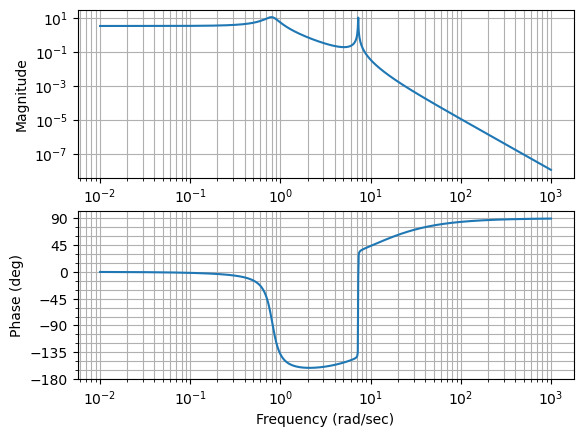

In [8]:
complex_magnitude = np.loadtxt('comp_mag.csv', delimiter=',', dtype=np.complex64)
f_vec = np.loadtxt('frequency.csv', delimiter=',', dtype=float)
na = 4  # number of poles of estimated transfer function
nb = 2  # number of zeros of estimated transfer function
G_measured = np.array(complex_magnitude)
# estimate the transfer function. G_measured is the frequency response of the system, 
# f_vec is a vector containing all the test frequencies that you used. 
theta = lu.fit_transfer_function_to_frequency_response([na, nb],G_measured,f_vec)
G_est = ct.tf(np.flip(theta[0:nb,0]), 
              np.concatenate(([1],np.flip(theta[nb:nb+na,0]))) )
print(G_est)
ct.bode_plot(G_est)

# TA Check

Call over a TA to look at your Bode plot. Be prepared to answer some questions about it. 

# Compare to Mathematical Model

In the lectures we have derived an expression for a transfer function that represents a Two-Disk system like the one in this lab. Use the code below to plot the Bode plot for this system. The plot will not match the Bode plot you constructed, because we do not know the moment of inertia, friction and spring constant for the lab setup. But the over all picture should be similar. Do you notice any similarities?


                1
---------------------------------
25 s^4 + 3.75 s^3 + 15.12 s^2 + s



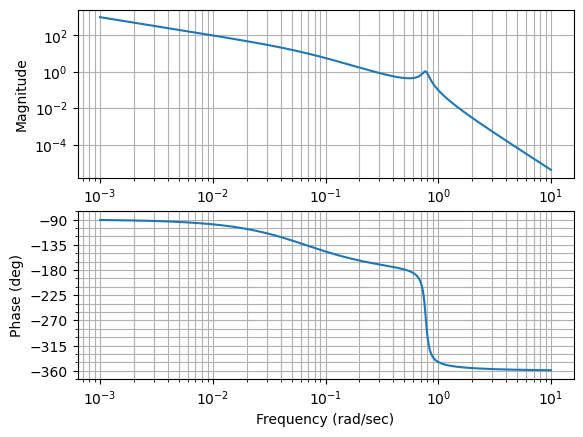

In [35]:
import control as ct
import numpy as np

J1 = 10
J2 = 5
k = 2
b = 0.5

num_sys = np.array([1])
den_sys = np.array([J1*J2/k, (J1+J2)*b/k, (J1+J2+b**2/k), 2*b, 0])

P = ct.tf(num_sys,den_sys)
print(P)

out = ct.bode_plot(P)


# Going Further (5% bonus)

Can you figure out values for $J1$, $J2$, $k$ and $b$ from the measured data?

# End of Lab

Submit a report that includes all the relevant plots and code. Include comments where appropriate. 